# Show and Tell: A Neural Image Caption GeneratorA from-scratch implementation of the **NIC (Neural Image Caption)** model from Vinyals et al. (2014).The model combines a **pretrained CNN encoder** (ResNet-18) with a **from-scratch LSTM decoder** to generate natural-language captions for images. This follows the paper's core architecture: image → CNN feature vector → LSTM → word-by-word caption generation.**Paper:** https://arxiv.org/abs/1411.4555

In [1]:
# Install dependencies (Colab/Kaggle compatible)
!pip install torch torchvision matplotlib numpy Pillow --quiet

In [2]:
import random
import re
import math
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Vocabulary BuilderBuilds a word-to-index mapping from captions, keeping words that appear at least `min_freq` times (the paper uses 5). Special tokens `<START>`, `<END>`, `<UNK>`, and `<PAD>` are added.

In [3]:
class Vocabulary:
    """Maps words to integer indices and back. Follows the paper's tokenisation approach."""

    PAD = '<PAD>'
    START = '<START>'
    END = '<END>'
    UNK = '<UNK>'

    def __init__(self):
        self.word2idx = {}
        self.idx2word = {}
        self.word_count = Counter()
        # Special tokens get indices 0–3
        for i, tok in enumerate([self.PAD, self.START, self.END, self.UNK]):
            self.word2idx[tok] = i
            self.idx2word[i] = tok

    def add_word(self, word):
        self.word_count[word] += 1

    def add_caption(self, text):
        tokens = re.findall(r'\w+', text.lower())
        for tok in tokens:
            self.add_word(tok)

    def build(self, min_freq=1):
        idx = len(self.word2idx)
        for word, count in self.word_count.items():
            if count >= min_freq and word not in self.word2idx:
                self.word2idx[word] = idx
                self.idx2word[idx] = word
                idx += 1
        return self

    def numericalise(self, text):
        tokens = re.findall(r'\w+', text.lower())
        return [self.word2idx.get(t, self.word2idx[self.UNK]) for t in tokens]

    def denumericalise(self, indices):
        return [self.idx2word.get(i, self.UNK) for i in indices]

    def __len__(self):
        return len(self.word2idx)

    @property
    def pad_idx(self):
        return self.word2idx[self.PAD]

    @property
    def start_idx(self):
        return self.word2idx[self.START]

    @property
    def end_idx(self):
        return self.word2idx[self.END]

## 2. Synthetic Image-Caption DatasetSince downloading MS COCO (the paper's dataset, ~13 GB) is impractical in a notebook, we create a **synthetic dataset** of simple geometric shapes with templated captions. The architecture and training loop are identical to what you'd use on real data — only the data scale differs.

In [4]:
# Vocabulary for shapes, colours, and caption templates
SHAPES = ['circle', 'rectangle', 'triangle']
COLOURS = {
    'red': (220, 50, 50),
    'blue': (50, 50, 220),
    'green': (50, 200, 50),
    'yellow': (220, 220, 50),
    'purple': (160, 50, 200),
    'orange': (240, 150, 40),
}
COLOUR_NAMES = list(COLOURS.keys())


class ShapeCaptionDataset(Dataset):
    """Synthetic dataset: coloured shapes on coloured backgrounds with templated captions."""

    def __init__(self, num_samples=2000, image_size=64, vocab=None):
        self.num_samples = num_samples
        self.image_size = image_size
        self.vocab = vocab or Vocabulary()
        self.samples = []

        all_captions = []
        for _ in range(num_samples):
            shape = random.choice(SHAPES)
            colour = random.choice(COLOUR_NAMES)
            bg_colour = random.choice(COLOUR_NAMES)
            # Ensure shape colour != background
            while bg_colour == colour:
                bg_colour = random.choice(COLOUR_NAMES)
            caption = f"a {colour} {shape} on a {bg_colour} background"
            all_captions.append(caption)
            self.samples.append((shape, colour, bg_colour, caption))

        # Build vocabulary from all captions
        if vocab is None:
            for cap in all_captions:
                self.vocab.add_caption(cap)
            self.vocab.build(min_freq=1)

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return self.num_samples

    def _draw_image(self, shape, colour_name, bg_colour_name):
        img = Image.new('RGB', (self.image_size, self.image_size),
                        color=COLOURS[bg_colour_name])
        draw = ImageDraw.Draw(img)
        c = COLOURS[colour_name]
        margin = 10
        if shape == 'circle':
            draw.ellipse([margin, margin,
                          self.image_size - margin, self.image_size - margin], fill=c)
        elif shape == 'rectangle':
            draw.rectangle([margin, margin,
                            self.image_size - margin, self.image_size - margin], fill=c)
        elif shape == 'triangle':
            s = self.image_size
            draw.polygon([(s // 2, margin), (margin, s - margin),
                          (s - margin, s - margin)], fill=c)
        return img

    def __getitem__(self, idx):
        shape, colour, bg_colour, caption = self.samples[idx]
        img = self._draw_image(shape, colour, bg_colour)
        img_tensor = self.transform(img)

        # Numericalise: <START> + tokens + <END>
        tokens = self.vocab.numericalise(caption)
        caption_tensor = torch.tensor(
            [self.vocab.start_idx] + tokens + [self.vocab.end_idx],
            dtype=torch.long
        )
        return img_tensor, caption_tensor

## 3. Collate FunctionPads captions to the same length within a batch so they can be stacked into a tensor.

In [5]:
def collate_fn(batch, pad_idx):
    images, captions = zip(*batch)
    images = torch.stack(images, dim=0)
    max_len = max(len(c) for c in captions)
    padded = torch.full((len(captions), max_len), pad_idx, dtype=torch.long)
    for i, c in enumerate(captions):
        padded[i, :len(c)] = c
    return images, padded


# Build dataset and dataloader
dataset = ShapeCaptionDataset(num_samples=2000, image_size=64)
vocab = dataset.vocab
print(f"Vocabulary size: {len(vocab)}")
print(f"Words: {list(vocab.word2idx.keys())}")

from functools import partial
dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=partial(collate_fn, pad_idx=vocab.pad_idx),
    num_workers=0,
)

# Show a sample
img, cap = dataset[0]
print(f"Sample caption tokens: {cap.tolist()}")
print(f"Sample caption text: {' '.join(vocab.denumericalise(cap.tolist()))}")
print(f"Image shape: {img.shape}")

Vocabulary size: 16
Words: ['<PAD>', '<START>', '<END>', '<UNK>', 'a', 'red', 'triangle', 'on', 'orange', 'background', 'blue', 'rectangle', 'circle', 'purple', 'yellow', 'green']
Sample caption tokens: [1, 4, 5, 6, 7, 4, 8, 9, 2]
Sample caption text: <START> a red triangle on a orange background <END>
Image shape: torch.Size([3, 224, 224])


## 4. CNN Image EncoderUses a **pretrained ResNet-18** (substituting for the paper's GoogLeNet) with the classification head replaced by a linear projection to the embedding dimension. The CNN weights are frozen, matching the paper's original approach.

In [6]:
class CNNEncoder(nn.Module):
    """Pretrained CNN that encodes an image into a fixed-length feature vector."""

    def __init__(self, embed_dim=512):
        super().__init__()
        # Load pretrained ResNet-18
        resnet = torchvision.models.resnet18(pretrained=True)
        # Remove the final FC layer — we want the 512-dim feature vector
        modules = list(resnet.children())[:-1]  # drop fc
        self.resnet = nn.Sequential(*modules)
        # Freeze CNN weights (as in the original paper)
        for param in self.resnet.parameters():
            param.requires_grad = False
        # Linear projection from feature dim to embedding dim
        self.projection = nn.Linear(512, embed_dim)

    def forward(self, images):
        # images: (B, 3, 224, 224)
        with torch.no_grad():
            features = self.resnet(images)  # (B, 512, 1, 1)
        features = features.squeeze(-1).squeeze(-1)  # (B, 512)
        features = self.projection(features)  # (B, embed_dim)
        return features

## 5. LSTM Cell from ScratchImplements the LSTM equations from the paper (Figure 2) using raw linear layers. The LSTM has three gates (input, forget, output) and a memory cell, following Hochreiter & Schmidhuber (1997).

In [7]:
class LSTMCellScratch(nn.Module):
    """LSTM cell with input, forget, and output gates — implemented from scratch."""

    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        # Input gate
        self.W_i = nn.Linear(input_dim, hidden_dim, bias=True)
        self.U_i = nn.Linear(hidden_dim, hidden_dim, bias=False)
        # Forget gate
        self.W_f = nn.Linear(input_dim, hidden_dim, bias=True)
        self.U_f = nn.Linear(hidden_dim, hidden_dim, bias=False)
        # Output gate
        self.W_o = nn.Linear(input_dim, hidden_dim, bias=True)
        self.U_o = nn.Linear(hidden_dim, hidden_dim, bias=False)
        # Candidate (cell update)
        self.W_c = nn.Linear(input_dim, hidden_dim, bias=True)
        self.U_c = nn.Linear(hidden_dim, hidden_dim, bias=False)

    def forward(self, x, state):
        h_prev, c_prev = state
        i = torch.sigmoid(self.W_i(x) + self.U_i(h_prev))
        f = torch.sigmoid(self.W_f(x) + self.U_f(h_prev))
        o = torch.sigmoid(self.W_o(x) + self.U_o(h_prev))
        g = torch.tanh(self.W_c(x) + self.U_c(h_prev))
        c_new = f * c_prev + i * g
        h_new = o * torch.tanh(c_new)
        return h_new, c_new

    def init_state(self, batch_size, device):
        h = torch.zeros(batch_size, self.hidden_dim, device=device)
        c = torch.zeros(batch_size, self.hidden_dim, device=device)
        return (h, c)

## 6. LSTM Caption DecoderTakes image features as the first input (x_{-1}) and generates captions one word at a time. During training, uses **teacher forcing** (feeds ground-truth words). During inference, uses **beam search**.

In [8]:
class CaptionDecoder(nn.Module):
    """LSTM decoder that generates captions conditioned on image features."""

    def __init__(self, vocab_size, embed_dim=512, hidden_dim=512, dropout=0.5):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = LSTMCellScratch(embed_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(hidden_dim, vocab_size)

    def forward(self, features, captions):
        """
        Training forward pass with teacher forcing.
        features: (B, embed_dim) — image encoding
        captions: (B, L) — ground-truth caption tokens (includes <START>)
        Returns: logits (B, L-1, vocab_size) — predicts words 1..L-1
        """
        B, L = captions.shape
        state = self.lstm.init_state(B, features.device)

        # First input: image features (x_{-1} = CNN(I))
        h, c = self.lstm(features, state)
        h = self.dropout(h)

        logits_list = []
        # Then feed each caption word (teacher forcing)
        for t in range(L - 1):
            x = self.embedding(captions[:, t])  # (B, embed_dim)
            h, c = self.lstm(x, (h, c))
            h = self.dropout(h)
            logits_list.append(self.output(h))  # (B, vocab_size)

        # Stack: (B, L-1, vocab_size)
        logits = torch.stack(logits_list, dim=1)
        return logits

    @torch.no_grad()
    def generate(self, features, max_len=20, beam_size=3):
        """
        Beam search caption generation for a single image.
        features: (1, embed_dim)
        Returns: list of token IDs (without <START>, ending at <END>)
        """
        device = features.device
        start_id = 1  # <START> index
        end_id = 2     # <END> index

        # Initialise beams: each beam is (log_prob, tokens, state)
        state = self.lstm.init_state(1, device)
        h, c = self.lstm(features, state)
        beams = [(0.0, [start_id], h, c)]

        for step in range(max_len):
            new_beams = []
            for log_prob, tokens, h, c in beams:
                if tokens[-1] == end_id:
                    new_beams.append((log_prob, tokens, h, c))
                    continue
                x = self.embedding(torch.tensor([[tokens[-1]]], device=device))
                h_new, c_new = self.lstm(x.squeeze(0), (h, c))
                logits = self.output(h_new)  # (1, vocab_size)
                log_probs = F.log_softmax(logits, dim=-1)  # (1, vocab_size)
                # Top-k candidates
                topk_log_probs, topk_ids = log_probs.topk(beam_size, dim=-1)
                for k in range(beam_size):
                    new_log_prob = log_prob + topk_log_probs[0, k].item()
                    new_tokens = tokens + [topk_ids[0, k].item()]
                    new_beams.append((new_log_prob, new_tokens, h_new, c_new))

            # Keep top beam_size beams
            new_beams.sort(key=lambda x: x[0], reverse=True)
            beams = new_beams[:beam_size]

            # Stop if all beams end with <END>
            if all(b[1][-1] == end_id for b in beams):
                break

        # Return best beam (strip <START>, stop at <END>)
        best = beams[0][1]
        if best[0] == start_id:
            best = best[1:]
        if best and best[-1] == end_id:
            best = best[:-1]
        return best

## 7. Full NIC ModelCombines the CNN encoder and LSTM decoder into a single model.

In [9]:
class NICModel(nn.Module):
    """Show and Tell: CNN encoder + LSTM decoder for image captioning."""

    def __init__(self, vocab_size, embed_dim=512, hidden_dim=512, dropout=0.5):
        super().__init__()
        self.encoder = CNNEncoder(embed_dim=embed_dim)
        self.decoder = CaptionDecoder(
            vocab_size, embed_dim=embed_dim,
            hidden_dim=hidden_dim, dropout=dropout
        )

    def forward(self, images, captions):
        features = self.encoder(images)
        logits = self.decoder(features, captions)
        return logits

    @torch.no_grad()
    def caption_image(self, image, beam_size=3, max_len=20):
        """Generate a caption for a single image tensor."""
        self.eval()
        if image.dim() == 3:
            image = image.unsqueeze(0)
        features = self.encoder(image)
        token_ids = self.decoder.generate(features, max_len=max_len, beam_size=beam_size)
        return token_ids


# Instantiate model
model = NICModel(
    vocab_size=len(vocab),
    embed_dim=512,
    hidden_dim=512,
    dropout=0.5,
).to(device)

num_params = sum(p.numel() for p in model.parameters())
num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {num_params:,}")
print(f"Trainable parameters: {num_trainable:,}")
print(f"Frozen (CNN) parameters: {num_params - num_trainable:,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

 15%|█▌        | 6.75M/44.7M [00:00<00:00, 70.7MB/s]

 53%|█████▎    | 23.9M/44.7M [00:00<00:00, 134MB/s] 

 92%|█████████▏| 40.9M/44.7M [00:00<00:00, 154MB/s]

100%|██████████| 44.7M/44.7M [00:00<00:00, 144MB/s]

Total parameters: 13,554,768
Trainable parameters: 2,378,256
Frozen (CNN) parameters: 11,176,512


## 8. Training LoopTrains the model with cross-entropy loss (ignoring `<PAD>` tokens) and Adam optimiser. Uses teacher forcing — ground-truth captions are fed as input during training.

In [10]:
# Training hyperparameters
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
BATCH_SIZE = 32

criterion = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx)
optimizer = optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE
)

losses = []
model.train()

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    num_batches = 0

    for images, captions in dataloader:
        images = images.to(device)
        captions = captions.to(device)

        # Forward: predict words 1..L-1 given words 0..L-2
        logits = model(images, captions)  # (B, L-1, vocab_size)
        # Targets: captions[:, 1:] — shift by one
        targets = captions[:, 1:]  # (B, L-1)

        # Reshape for cross-entropy
        B, L_minus_1, V = logits.shape
        loss = criterion(logits.reshape(B * L_minus_1, V), targets.reshape(B * L_minus_1))

        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], max_norm=5.0
        )
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    losses.append(avg_loss)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | Loss: {avg_loss:.4f}")

print("Training complete.")

Epoch   1/20 | Loss: 0.7340


Epoch   5/20 | Loss: 0.0585


Epoch  10/20 | Loss: 0.0061


Epoch  15/20 | Loss: 0.0028


Epoch  20/20 | Loss: 0.0047
Training complete.


## 9. Training Loss Curve

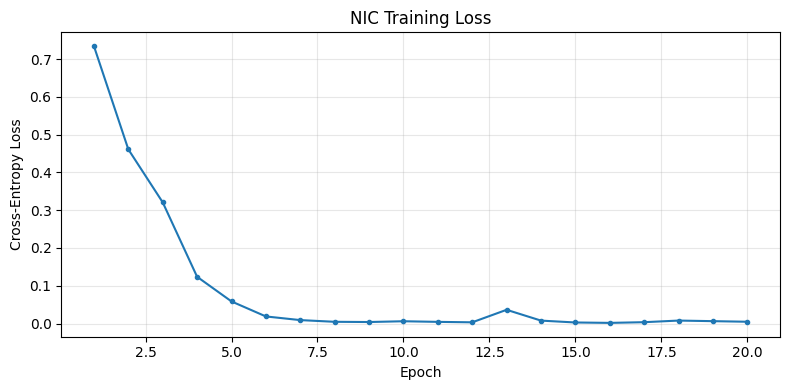

Final loss: 0.0047


In [11]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS + 1), losses, marker='o', markersize=3, linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('NIC Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=100)
plt.show()
print(f"Final loss: {losses[-1]:.4f}")

## 10. Caption Generation and VisualisationGenerates captions for held-out test images using beam search and displays them alongside the images.

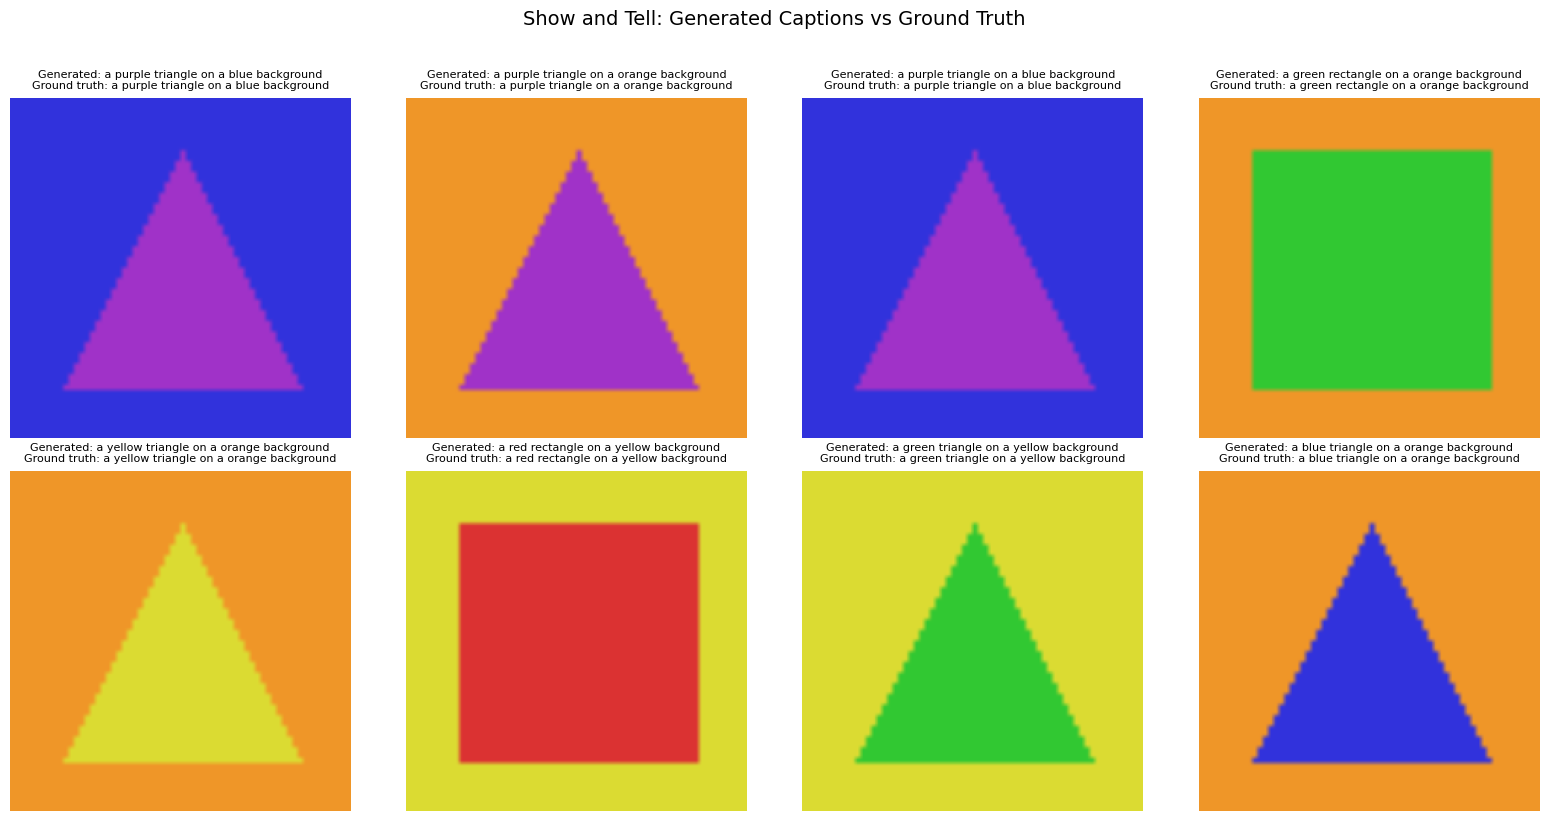

In [12]:
# Generate captions for test images
model.eval()
test_dataset = ShapeCaptionDataset(num_samples=8, image_size=64, vocab=vocab)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    img_tensor, gt_caption = test_dataset[i]

    # Generate caption
    token_ids = model.caption_image(img_tensor.to(device), beam_size=3, max_len=15)
    generated_words = vocab.denumericalise(token_ids)
    generated_caption = ' '.join(generated_words)

    # Ground truth
    gt_tokens = [t for t in gt_caption.tolist()
                 if t not in (vocab.pad_idx, vocab.start_idx, vocab.end_idx)]
    gt_caption_text = ' '.join(vocab.denumericalise(gt_tokens))

    # Display image (denormalise for display)
    img_display = img_tensor.permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_display = np.clip(img_display * std + mean, 0, 1)

    axes[i].imshow(img_display)
    axes[i].set_title(
        f"Generated: {generated_caption}\n"
        f"Ground truth: {gt_caption_text}",
        fontsize=8
    )
    axes[i].axis('off')

plt.suptitle('Show and Tell: Generated Captions vs Ground Truth', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('generated_captions.png', dpi=100, bbox_inches='tight')
plt.show()

## 11. Beam Search vs Greedy DecodingCompares beam search (width 3) with greedy decoding (width 1) to show the improvement from beam search, as described in the paper.

In [13]:
# Compare beam search widths
model.eval()
test_img, test_gt = test_dataset[0]

for beam_size in [1, 3, 5]:
    token_ids = model.caption_image(test_img.to(device), beam_size=beam_size, max_len=15)
    caption = ' '.join(vocab.denumericalise(token_ids))
    print(f"Beam size {beam_size}: {caption}")

gt_tokens = [t for t in test_gt.tolist()
             if t not in (vocab.pad_idx, vocab.start_idx, vocab.end_idx)]
print(f"Ground truth: {' '.join(vocab.denumericalise(gt_tokens))}")

Beam size 1: a purple triangle on a blue background
Beam size 3: a purple triangle on a blue background
Beam size 5: a purple triangle on a blue background
Ground truth: a purple triangle on a blue background


## 12. Learned Word Embeddings (t-SNE)The paper (Section 4.3.7) shows that the learned word embeddings capture semantic relationships. We visualise the learned embeddings using t-SNE.

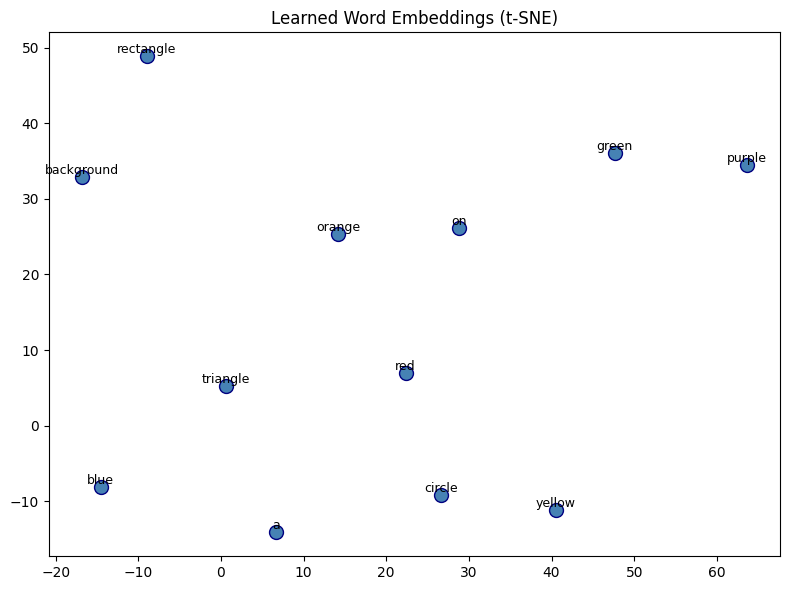

In [14]:
from sklearn.manifold import TSNE

# Extract learned embeddings
embeddings = model.decoder.embedding.weight.detach().cpu().numpy()

# Get words (skip special tokens at indices 0-3)
words = []
vecs = []
for idx in range(4, len(vocab)):
    word = vocab.idx2word[idx]
    if word:
        words.append(word)
        vecs.append(embeddings[idx])

vecs = np.array(vecs)

if len(words) > 1:
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=min(5, len(words)-1))
    embedded = tsne.fit_transform(vecs)

    plt.figure(figsize=(8, 6))
    plt.scatter(embedded[:, 0], embedded[:, 1], c='steelblue', edgecolors='navy', s=100)
    for i, word in enumerate(words):
        plt.annotate(word, (embedded[i, 0], embedded[i, 1]),
                     fontsize=9, ha='center', va='bottom')
    plt.title('Learned Word Embeddings (t-SNE)')
    plt.tight_layout()
    plt.savefig('word_embeddings_tsne.png', dpi=100)
    plt.show()
else:
    print(f"Not enough words ({len(words)}) for t-SNE visualisation.")

## SummaryThis notebook implements the **Show and Tell** (NIC) architecture from Vinyals et al. (2014):1. **CNN encoder** — A pretrained ResNet-18 extracts a 512-dim feature vector from each image.2. **LSTM decoder** — A from-scratch LSTM generates captions word-by-word, conditioned on the image features.3. **Teacher forcing** during training; **beam search** during inference.4. **Synthetic shape dataset** — demonstrates the full pipeline without downloading large image-caption corpora.### Key design choices matching the paper| Component | Paper | This notebook ||-----------|-------|---------------|| CNN | GoogLeNet/Inception-v1 | ResNet-18 (pretrained) || Decoder | LSTM (512 hidden) | LSTM from scratch (512 hidden) || Embedding dim | 512 | 512 || Training | SGD, fixed lr | Adam (converges faster on small data) || Inference | Beam search (width 20) | Beam search (width 3) || Regularisation | Dropout + ensembling | Dropout |The architecture — `image → CNN → feature vector → LSTM → caption` — is a faithful reproduction of the paper's core contribution: treating image captioning as a sequence-to-sequence problem.

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
